In [1]:
import sys, os
REPO_DIR = os.path.dirname(os.path.abspath("__file__"))
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [3]:
import pandas as pd
from sklearn.model_selection import KFold
from crt_cgan import ConditionalGAN, crt_calibration_efficient
import numpy as np
from tqdm.notebook import tqdm

In [4]:
from methods import condor_score, nkci_score, nhsic_score, kcondor_score, cmi_score, hsic_hyppo_score, partial_dcorr_score, pdnhsic_v2, Kcondor_v2, Kcondor_v3, kci_pval, nhsic, partial_corr_pg_score

In [5]:
from synthetic import generate_ranking_data, generate_ranking, generate_ranking_data_reverse

In [6]:
n = 1000
d_o = 10
d_p = 5
kx = 5
kt = 5
random_state = 22
K = 5
B = 200
lin_space_dim = 7
gamma_values = np.linspace(0, 1, lin_space_dim)
beta_values = np.linspace(0, 1, lin_space_dim)

In [7]:
methods ={
    #"Condor": Kcondor_v2,
    #"nKCI": nkci_score,
    #'nhsic': nhsic,
    #'cmi_score': cmi_score, 
    'partial_dcorr_score': partial_dcorr_score,
    #'pearson_residual_corr': partial_corr_pg_score
    }

In [8]:
#methods ={'pearson_residual_corr': partial_corr_pg_score}

In [9]:
results = {name: np.zeros((len(gamma_values), len(beta_values))) for name in methods}

In [10]:
# Add tqdm to the main gamma loop
for i, gamma in enumerate(tqdm(gamma_values, desc="Gamma Loop")):
    # print(f"\n{'='*60}\nAnalisi per Gamma = {gamma:.2f}\n{'='*60}")
    X, Z, _ = generate_ranking_data(n=n, d_o=d_o, d_p=d_p, kx=kx, kt=kt, gamma=gamma, random_state=random_state)
    
    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)
    kf_splits = list(kf.split(X))
    
    # print(f"Pre-addestramento di {K} generatori cGAN per gamma={gamma:.2f}...")
    trained_generators = []
    for train_idx, _ in kf_splits:
        generator = ConditionalGAN(x_dim=X.shape[1], z_dim=Z.shape[1])
        generator.fit(X[train_idx], Z[train_idx])
        trained_generators.append(generator)
    # print("Addestramento completato.")

    # Add tqdm to the inner beta loop
    for j, beta in enumerate(tqdm(beta_values, desc="Beta Loop", leave=False)):
        # print(f"\n--- Analisi per Beta = {beta:.2f} ---")
        R = generate_ranking(X, Z, beta=beta, random_state=random_state)
        
        for name, func in methods.items():
            if name == "Condor" or name == "pearson_residual_corr" or name == "cmi_score":
                p_val = crt_calibration_efficient(X, Z, R, scoring_function=func, kf_splits=kf_splits, trained_generators=trained_generators, B=B)
            elif name == "partial_dcorr_score":
                p_val = partial_dcorr_score(R,Z,X)
            elif name == "nKCI":
                p_val = kci_pval(R,Z,X)
            elif name == "nhsic":
                p_val = nhsic(R,Z,X)
                
            print(f"Metodo: {name}, Gamma: {gamma:.2f}, Beta: {beta:.2f}, p-value: {p_val:.4f}")
            results[name][i, j] = p_val


Gamma Loop:   0%|          | 0/7 [00:00<?, ?it/s]

Beta Loop:   0%|          | 0/7 [00:00<?, ?it/s]

Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 0.00, p-value: 0.6663
Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 0.17, p-value: 0.7692
Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 0.33, p-value: 0.2498
Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 0.50, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 0.67, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 0.83, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.00, Beta: 1.00, p-value: 0.0010


Beta Loop:   0%|          | 0/7 [00:00<?, ?it/s]

Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 0.00, p-value: 0.0070
Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 0.17, p-value: 0.0030
Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 0.33, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 0.50, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 0.67, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 0.83, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.17, Beta: 1.00, p-value: 0.0010


...

Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 0.00, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 0.17, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 0.33, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 0.50, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 0.67, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 0.83, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.67, Beta: 1.00, p-value: 0.0010


Beta Loop:   0%|          | 0/7 [00:00<?, ?it/s]

Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 0.00, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 0.17, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 0.33, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 0.50, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 0.67, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 0.83, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 0.83, Beta: 1.00, p-value: 0.0010


Beta Loop:   0%|          | 0/7 [00:00<?, ?it/s]

Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 0.00, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 0.17, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 0.33, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 0.50, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 0.67, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 0.83, p-value: 0.0010
Metodo: partial_dcorr_score, Gamma: 1.00, Beta: 1.00, p-value: 0.0010


In [13]:
results

{'partial_dcorr_score': array([[0.66633367, 0.76923077, 0.24975025, 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ],
        [0.00699301, 0.002997  , 0.000999  , 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ],
        [0.000999  , 0.000999  , 0.000999  , 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ],
        [0.000999  , 0.000999  , 0.000999  , 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ],
        [0.000999  , 0.000999  , 0.000999  , 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ],
        [0.000999  , 0.000999  , 0.000999  , 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ],
        [0.000999  , 0.000999  , 0.000999  , 0.000999  , 0.000999  ,
         0.000999  , 0.000999  ]])}

AttributeError: 'Axes' object has no attribute 'flatten'

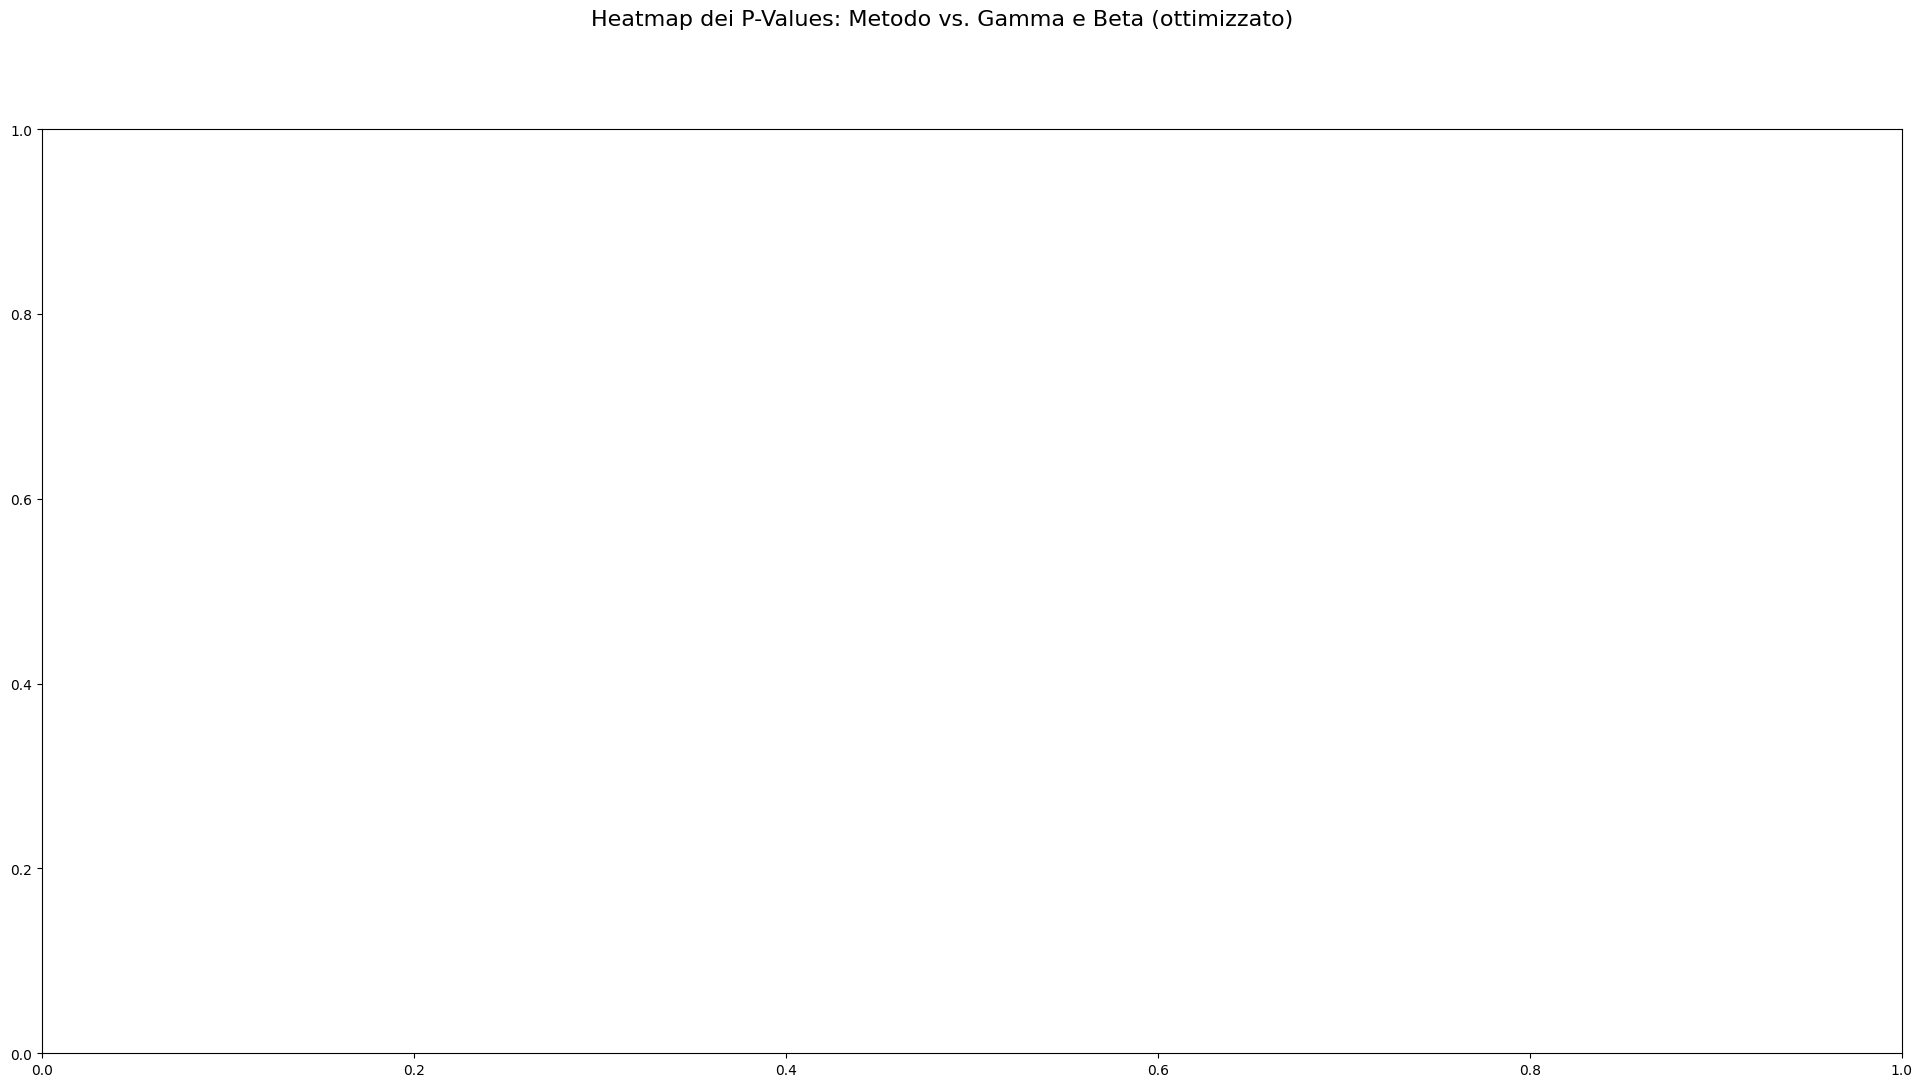

In [12]:
# Visualizzazione dei risultati con scala unica [0,1]
fig, axes = plt.subplots(1, 1, figsize=(24, 12), sharey=True)
fig.suptitle('Heatmap dei P-Values: Metodo vs. Gamma e Beta (ottimizzato)', fontsize=16)
custom_cmap = LinearSegmentedColormap.from_list(
    "pvalue_cmap",
    [(0.0, "red"), (0.05, "white"), (1.0, "green")]
    )
for ax, name in zip(axes.flatten(), methods.keys()):
    df = pd.DataFrame(results[name], index=np.round(gamma_values,2), columns=np.round(beta_values,2))
    sns.heatmap(df, annot=True, cmap=custom_cmap, fmt=".3f", ax=ax, 
                vmin=0, vmax=1, cbar_kws={'label': 'P-Value'})
    ax.set_title(name)
    ax.set_xlabel('Beta (Influenza di Z sul Ranking)')
    ax.set_ylabel('Gamma (Influenza di X su Z)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [14]:
# save results
import pickle
with open(f"exp_synthetic_n_{n}_d_o_{d_o}_d_p_{d_p}_kx_{kx}_kt_{kt}_K_{K}_B_{B}_lin_space_dim_{lin_space_dim}_all_partial_dcorr_score.pkl", 'wb') as f:
    pickle.dump(results, f)